# Home work - Atomic Radii

# ✔  Supervised Learning

**Linear Regression / Polynomial Regression & Random Forest**

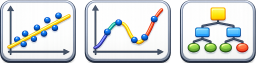

The data set : elements.csv consists of the variables 

Element,Atomic_Number,Period,Group,Electronegativity,Atomic_Radius_pm.

Our dependent variable or target (y) is the atomic radius and all others can be independent variables (X).

Our objective is to build a model where we can take one or more of the independent (X) variables and accurately predict the target (y).

We will check how well it  fits with linear models, and then try something new - Random Forests. -- We are jumping way ahead with this one, because we haven't learnt it yet. But consider this a early preview.

In [ ]:
#We usually import all the necessary packages at the top - keeps the code clean
#Essential packages - numpy, pandas, matplotlib, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math
#ML packages
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report


#If you need to add a package half-way through the code, you can - there's nothing technically wrong with it
#But as a best practice you should come back up and add it here, and then RUN the cell (and run all the following cells)

In [ ]:
df=pd.read_csv("lec03-Atomic_radii.csv")

In [ ]:
#Inspect the data - very important to 'see' the data that we are dealing with
df.head(10)

In [ ]:
#There seems to be some missing data
df.isna()


# ❓ Can you get a summarised version of the above?

**useful when you have a big dataset**

In [ ]:
df.isna().sum()

# ⁉ How to deal with missing data

Option 1: Delete them from the dataset

*   If you have a big dataset and deleting a few values doesn't affect the outcome
*   The rows/columns containing the missing data is not relevant for your calculation

```
# df = df.dropna(axis=1,how="any") # drop the entire column containing missing values
# df = df.dropna(axis=0,how="any") # drop the entire column containing missing values
```

Option 2: Insert the missing values using reference database
*   If the dataset is too small and every datapoint is important
*   If the number of missing datapoints are small enough to be manually inserted

Option 3: Impute the missing value using a statistical basis
*   Using the mean/median/mode value of the rest of the column
*   The error introduced is not significant in the final outcome

- code shown below

In [ ]:
#Let's check the length of the data - can you afford to delete the missing data?
#use the len() function
len(df)

In [ ]:
# Fill missing EN (noble gases) with mean for simplicity
df["Electronegativity"] = df["Electronegativity"].fillna(df["Electronegativity"].mean())
df.head(10)

In [ ]:
#Just double checking
df.isna().sum()

In [ ]:
#Separating the X (independent) and y (dependent) variables for convenience
y = df[["Atomic_Radius_pm"]]
X = df[["Atomic_Number"]]

In [ ]:
#checking the data tyype of X
type(X)

In [ ]:
#Let's plot this to see
plt.figure(figsize=(10,5))
plt.scatter(df["Atomic_Number"], df["Atomic_Radius_pm"],color='magenta',marker='x')
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()

# ⚡ Train - Test Split

When we build a ML model we don't use the whole dataset to do it.
Instead, we split it into two (sometimes three) sets, called training, testing (and validation) datasets.
Training set - majority of the data (generally 60%-80%)
Testing set - small portion (20%-25% is common)
Validation set - Only needed if you are using data to make modeling decisions (tune hyper-parameters/ choose models/ choose features etc.) (~20%)

❓**Why do we split the data?**

We build the model on the training data, and test the performance using test data. So it acts as an independent evaluation of the model performance. So ideally the model should not 'see' the test data during training time. This means there should be no duplicates (across train and test), there should be no statistics of the overal distribution in the test set (i.e. should not normalize the dataset before splitting)

In [ ]:
#for this we will do a simple train/test split
#If you need a validation set, you can simply use this same function twice
#Use train_test_split() function

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=41)
X_train.head()


In [ ]:
#Print the train/test set lengths to confirm
print("length of X train:",len(X_train),"& length of y train",len(y_train))
print("length of X test:",len(X_test),"& length of y test",len(y_test))

In [ ]:
X_train.columns #Just checking

In [ ]:
y_train.columns

In [ ]:
#Let's try Linear Regression (simplest scenario) ::  Look up the Scikit-learn documentation
#We need to first create an instance of the Class (which inherits all its functions and attributes from the parent class)
model = LinearRegression()

#fit our training data
# use fit() function
model.fit(X_train, y_train)

print("R²:", model.score(X_train,y_train))



In [ ]:
#LinearRegression class has two variables (attributes) called coef_ and intercept_
#model.coef_
#model.intercept_
print(f"coefficient is: {model.coef_}, and intercept is : {model.intercept_}")

In [ ]:
#Let's use this model on the X training data to make predictions and compare with actual values
y_train_predict = model.predict(X_train)

plt.figure(figsize=(10,5))
plt.scatter(X_train,y_train) #Original data
plt.plot(X_train,y_train_predict) #Predicted data - add some colour
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()


#Another metric that can be checked is mean absolute error

❓  Look up the Scikit-learn documentation on Mean absolute error (MAE), and write a code to compute the MAE value for the training data.

Alternatives: Mean Squared Error (MSE), Root Mean Squared Error (RMSE)

In [ ]:
#MAE  - overal good metric
mae_train = mean_absolute_error(y_train,y_train_predict)
print(mae_train)
#MSE  - sensitive to outliers
mse_train = mean_squared_error(y_train,y_train_predict)
print(mse_train)

#TO compare MAE Vs MSE, use RMSE
rmse = math.sqrt(mse_train)
print(rmse)

In [ ]:
#Residual plot
plt.scatter(y_train, y_train - y_train_predict)
plt.axhline(0,color='red')

# 🧪 Testing
If you want to test the model  : need to use the test datasets

You can use the same metrics / plots to see how well the model performs


**❓Find the r2 value and the MAE for the Test set**

**❓Then plot the original test data & the regression line**

 What do you think?

In [ ]:
# r2 test
r2_test= model.score(X_test,y_test)
print("R² test:", r2_test)
# MAE test
mae_test = mean_absolute_error(y_test,model.predict(X_test))
print("MAE test:",mae_test)

In [ ]:
# plot test
y_test_predict = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.scatter(X_test,y_test) #Original data
plt.plot(X_test,y_test_predict,color='green') #Predicted data
plt.xlabel("Atomic Number")
plt.ylabel("Atomic Radius (pm)")
plt.title("Test data: Periodic Trend of Atomic Radius (Z=1–36)")
plt.show()


💡 We only used one x variable (Atomic number) for our prediction, but the model would be more accurate if you used other variables like Period or Group.

➡ This means multi-variable regression (but still linear).

Multi-variable regression is where you use multiple features to predict one outcome.

In [ ]:
#Let's add a few more X variables (multi-variable)

X_multi = df[["Atomic_Number","Period","Group"]]
y = df["Atomic_Radius_pm"]

#Split the data
X_multi_train,X_multi_test,y_train,y_test = train_test_split(X_multi,y,test_size=0.2,random_state=42)

#New model now
model_multi = LinearRegression()
model_multi.fit(X_multi_train,y_train)

print("R²:", model_multi.score(X_multi_train,y_train))

# ❓ Can you obtain the coefficients of the multi-variable model

This time, since it's a multi-variable regression, you should get multiple coefficients (how many?)

In [ ]:
#Coefficients of the multi-variable model
model_multi.coef_

In [ ]:
# MAE of the multi-variable model
y_train_predict = model.predict(X_train)
mae_train = mean_absolute_error(y_train,y_train_predict)
print("MAE:",mae_train)

mse_train = mean_squared_error(y_train,y_train_predict)
print("RMSE:",math.sqrt(mse_train))


#  🪱 Let's try a polynomial fit

Although Polynomial curves are non-linear, in python we still use the same linear algebra tools as linear regression - so it is still a linear model

In [ ]:
#let's start with a degree 2, (and try 3,4,5)

degree = 5
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X_train)

model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
print("R^2 with polynomial:", model_poly.score(X_poly, y_train))

In [ ]:
#Let's plot the polynomials and see
# Create smooth X values
X_plot = np.linspace(X_train.values.min(), X_train.values.max(), 200).reshape(-1, 1)

# Transform them
X_plot_poly = poly.transform(X_plot)

# Predict
y_plot = model_poly.predict(X_plot_poly)

# Plot
plt.figure()
plt.scatter(X_train, y_train)
plt.plot(X_plot, y_plot,color='magenta')
plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Fit (Degree = {degree})")
plt.show()

In [ ]:
#Maybe it's better to try with multi-variable regression -We can't visualize this

multi_poly = PolynomialFeatures(degree=2)
X_multi_poly = multi_poly.fit_transform(X_multi_train)

model_multi_poly = LinearRegression()
model_multi_poly.fit(X_multi_poly, y_train)
print("R^2 with polynomial:", model_multi_poly.score(X_multi_poly, y_train))

In [ ]:
#How do we know which polynomial degree would work best?

mae_arr = []
r2_arr = []

for degree in range(1,6):   #iterate through a range of degree values
    poly_features = PolynomialFeatures(degree=degree,include_bias=False)
    X_multi_poly = poly_features.fit_transform(X_multi_train)  #for each degree, preapre the polynomial fitting

    model_multi_poly =LinearRegression()
    model_multi_poly.fit(X_multi_poly,y_train)  #for each degree, fit a polynomial regression

    y_multi_poly = model_multi_poly.predict(X_multi_poly)
    mae = mean_absolute_error(y_train, y_multi_poly) #for each fit, predict the values and calculate the mse ,
    mae_arr.append(mae)  #save each of the calculated mse values in the array one after another
    r2 = r2_score(y_train, y_multi_poly)
    r2_arr.append(r2)

print(f"MAE: {mae_arr}")
print(f"R2: {r2_arr}")

In [ ]:
plt.plot(range(1,6),mae_arr,color='magenta',marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("MAE")
plt.title('Elbow method')
plt.show()

In [ ]:
#Pick the degree with the optimum MAE
best_degree = 3  # +1 because range starts at 1
print(f"Best polynomial degree : {best_degree}")

#Plotting is not straightforward since this is multi-dimensional

# Write the code to fit the optimum polynomial and obtain the metrics and coefficients


In [ ]:
#Optimum polynomial

multi_poly = PolynomialFeatures(best_degree)
X_multi_poly = multi_poly.fit_transform(X_multi_train)

model_multi_poly = LinearRegression()
model_multi_poly.fit(X_multi_poly, y_train)
print("R^2 with polynomial:", model_multi_poly.score(X_multi_poly, y_train))

y_multi_poly = model_multi_poly.predict(X_multi_poly)
mae_multi_poly = mean_absolute_error(y_multi_poly,y_train)
print("MAE for multi variable polynomial :",mae_multi_poly)

# ❗ A high r2 does not necessarily mean the fit is good!

- A polynomial can mathematically approximate this pattern, but that does not mean it is a physically meaningful model. ⭐The science doesn't add up.

- r2 squared is a measure of variance explained - it simply means that and not science explained

A flexible curve can follow the up-down oscillations and reduce residual error, which is specially true when data set is small, polynomial degree is high & periodic structure exists.

- The X variables are not independent features - more on this later.



# 🌳🌳 Random Forest Regressor

A Random forest is a collection of decision trees - a powerful classical ML algorithm widely used in Materials science.

It has many parameters and flexibility to adapt to different conditions, including non-linear relationships.

It can also be adapted for regression problems (RF Regressor) or classification problems (RF Classifier)

In [ ]:
#Let's start by creating an instance of it
rf = RandomForestRegressor(n_estimators=200, random_state=42,max_features="sqrt")
rf.fit(X_multi_train,y_train)

print("RF R²:", rf.score(X_multi_train,y_train))

# Visualization
Random forests are not easy to visualize, but to understand what's happening
we can visualize a single tree

For this we will need to install a specialized package called graphviz

In [ ]:
!apt-get install graphviz
!pip install graphviz

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

tree = rf.estimators_[0]

dot_data = export_graphviz(tree,
                           filled=True,
                           rounded=True,
                           feature_names=["X1","X2","X3"],
                           out_file=None)

graph = graphviz.Source(dot_data)
graph

# ❓
It's a bit confusing to see X1, X2 & X3 in the tree,

Can you modify them so that the actual feature names are displayed rather than variable names?

*X_multi = df[["Atomic_Number","Period","Group"]]*

In [ ]:
#modify the above code to use the column names instead of X1,X2 & X3

from sklearn.tree import export_graphviz
import graphviz

tree = rf.estimators_[0]

dot_data = export_graphviz(tree,
                           filled=True,
                           rounded=True,
                           feature_names=X_multi.columns,
                           out_file=None)

graph = graphviz.Source(dot_data)
graph


In [ ]:
# Which features are more important in determining the prediction of the target
importances = rf.feature_importances_
plt.bar(X_multi_train.columns,importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

# 📊 ❓
Can you sort these features in order and plot, so that it's easier to see

In [ ]:
#Sort the importance
importances = rf.feature_importances_   #indices = np.argsort(importances)[::-1] - for descending order
indices = np.argsort(importances)
#plot
plt.bar(X_multi_train.columns[indices], importances[indices])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

#Let's evaluate the performance of the Random Forest Regressor

Use the Test set, compute the r2 value

In [ ]:
# Predict on test set
y_test_pred = rf.predict(X_multi_test)

# Compute R²
r2_test = r2_score(y_test, y_test_pred)

print("Test R²:", r2_test)

# Over-fitting Vs Under-fitting
:
Look at the r2 values for the training and testing sets, If:

Train ≫ Test → Overfitting

Train ≈ Test → Good generalization

Both low → Underfitting

# ❔ What to do in case of Over / Under fit

 - Modify parameters of the model - more on that later!
 - Cross Validation - more on that later!
 -------------------------------------------------------------------------------


# 🌳🌳 Random Forest Classifier

For a classification problem we need two (or more) classes of data.

Since our data is not inherently classified, let's break it into two classes.

Light elements : atomic radius <100 pm

Heavy elements : atomic radius >=100 pm

Then build a model so that if we present the model with an unknown datpoint, it can correctly classify whether it is light or heavy only based on the X values

In [ ]:
# Threshold
threshold = 100

df["Light_Heavy"] = np.where(
    df["Atomic_Radius_pm"] < threshold,
    0,   # 0 = Light
    1    # 1 = Heavy
)

df[["Element","Atomic_Radius_pm","Light_Heavy"]].head()

In [ ]:
X_class = df[["Atomic_Number","Period","Group","Electronegativity"]]
y_class = df["Light_Heavy"]
X_class.head()

In [ ]:
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

In [ ]:
#For this we use Rnadom forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_clf.fit(X_class_train, y_class_train)

print("Train Accuracy:", rf_clf.score(X_class_train, y_class_train))
print("Test Accuracy:", rf_clf.score(X_class_test, y_class_test))

In [ ]:
#Based on the test set, predict what the outcome is according to the model
y_class_pred = rf_clf.predict(X_class_test)

print("\nClassification Report:")
print(classification_report(y_class_test, y_class_pred))

In [ ]:
print(importances)
print(len(importances))
print(X.columns)

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_class_test, y_class_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["Light", "Heavy"],
            yticklabels=["Light", "Heavy"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

In [ ]:
#Feature importance for classification
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print
plt.bar(X_class.columns[indices], importances[indices])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# 🔥 In Summary

- Import data
- Brief data exploration & cleaning
- Train - test split
- Linear Regression
  - single variable
  - multi-variable
- Polynomial Regression
  - single variable
  - multi-variable
  - finding optimum polynomial degrees
- Considerations in interpreting performance metrics
- Random Forest
  - Regression
  - Classification

